In [1]:
# Dictionary management and basic operations 
import numpy as np
import pandas as pd

#import statsmodels.api as sm
# library that allows to build Bayesian models
import pymc as pm

# Interval analysis and performance of the models. Tasked to determine significance in the variables and to find the most robust combination of variables.
import arviz as az

# Libraries for graphic representation and plotting data
import matplotlib.pyplot as plt
import seaborn as sns

# Test to evaluate the predicting power of the trained models
from lifelines.utils import concordance_index

# Poisson distribution cte.
from scipy.stats import poisson

In [2]:
# Simulate a dataset with an event rate of 0.0876
n = 236
np.random.seed(42)

# Categorical variable (CHAD2DS2VASc, HAS BLED,...)
X1 = np.random.randint(1, 9, n) 

# Numerical variable (Age)
X2_center = np.random.uniform(45, 95, n) - 73.0

# Numerical variable (IMC) 
X3_center = np.random.uniform(18, 35, n) - 28.4

# Time variable 
time = np.random.uniform(0.5, 5, n)

# We define the expected weights for each variable (Betas)
beta1_real, beta2_real, beta3_real = 0.14, 0.03, -0.025 

# We define the model without the intercept (beta0)
weights = beta1_real*X1 + beta2_real*X2_center + beta3_real*X3_center

# Caluclate the exact beta0 to archieve a rate of 0.087
# E[lambda] = exp(beta0) * mean(exp(carga_riesgo))
# beta0 = ln(0.0876) - ln(mean(exp(carga_riesgo)))
obj_rate= 0.0876
beta0_real = np.log(obj_rate) - np.log(np.mean(np.exp(weights)))

# Generate the individual rates and events 
log_lambda = beta0_real + weights
lambda_i = np.exp(log_lambda)
events = np.random.poisson(lambda_i * time)

#Store all the variables inside a pandas dataframe
df_sim = pd.DataFrame({
    'events': events, 'X1': X1, 'X2_center': X2_center, 
    'X3_center': X3_center, 'times': time
})

# Empirical test:
sim_rate = df_sim['events'].sum() / df_sim['times'].sum()

print(f"Global simulated rate(Events / Time): {sim_rate:.4f} events/time")
print("-" * 50)

# Training of the bayesian model using PyMC
print("Compiling and training the Bayesian model (MCMC)...")

with pm.Model() as modelo_bglm:
    
    # We select an objective, non-informative prior (Jeffrey's) to avoid the influence of previous knowledge
    beta0 = pm.Flat('Intercepto')
    beta1 = pm.Flat('X1_CHA2DS2VASc')
    beta2 = pm.Flat('X2_Edad')
    beta3 = pm.Flat('X3_IMC')
    
    # 2. Link function (Logarithmic)
    log_lambda_eq = (beta0 + 
                     beta1 * df_sim['X1'].values + 
                     beta2 * df_sim['X2_center'].values + 
                     beta3 * df_sim['X3_center'].values)
    
    # 3. Expected rate (w/ time offset)
    # E[Y] = lambda * t
    lambda_tasa = pm.Deterministic('lambda', pm.math.exp(log_lambda_eq))
    e_rate = pm.math.exp(log_lambda_eq) * df_sim['times'].values
    
    # 4. Likelihood (Distribution of observed data)
    obs = pm.Poisson('obs_rate', mu=e_rate, observed=df_sim['events'].values)
    
    # 5. Sampling (MCMC - NUTS)
    # 4 chains, 2000 tune and 5000 sampling iterations
    trace = pm.sample(draws=5000, tune=2000, chains=4, random_seed=42)

# Analysis of results
print("\n--- SUMMARY OF THE POSTERIOR DISTRIBUTION (94% HDI) ---")

# ArviZ's summary table
summary = az.summary(trace, var_names=["~lambda"], filter_vars="like", hdi_prob=0.94)
print(summary[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat']])

Global simulated rate(Events / Time): 0.0841 events/time
--------------------------------------------------
Compiling and training the Bayesian model (MCMC)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercepto, X1_CHA2DS2VASc, X2_Edad, X3_IMC]


Output()

Sampling 4 chains for 2_000 tune and 5_000 draw iterations (8_000 + 20_000 draws total) took 47 seconds.



--- SUMMARY OF THE POSTERIOR DISTRIBUTION (94% HDI) ---
                 mean     sd  hdi_3%  hdi_97%  r_hat
Intercepto     -2.646  0.317  -3.242   -2.054    1.0
X1_CHA2DS2VASc  0.021  0.061  -0.093    0.136    1.0
X2_Edad         0.035  0.010   0.016    0.054    1.0
X3_IMC         -0.025  0.027  -0.076    0.025    1.0


--- INCIDENCE RATE RATIOS (IRR) with 94% HDI ---


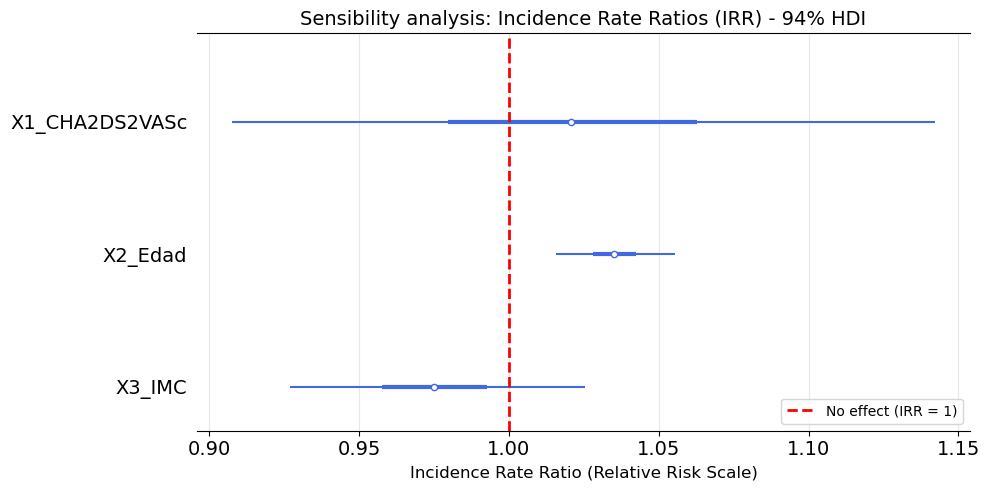

In [3]:
# IRR computations
# Conversion of the posterior distribution into an exponential function
posterior_irr = np.exp(trace.posterior)

# Statistical summary of the IRR intervals
summary_irr = az.summary(posterior_irr, hdi_prob=0.94)

print("--- INCIDENCE RATE RATIOS (IRR) with 94% HDI ---")

# Forest plot of the IRR intervals to visualize if the cross the neutral value (1.0)
fig, ax = plt.subplots(figsize=(10, 5))

# Apply plot_forest (ArviZ) without the intercept
az.plot_forest(
    posterior_irr, 
    var_names=['X1_CHA2DS2VASc', 'X2_Edad', 'X3_IMC'], # Dependent on the labels used
    hdi_prob=0.94, 
    combined=True,       # Combination of the MCMC chains together
    colors='royalblue',
    ax=ax
)

# Critical reference line (IRR = 1)
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='No effect (IRR = 1)')

# Graph's format
ax.set_title('Sensibility analysis: Incidence Rate Ratios (IRR) - 94% HDI', fontsize=14)
ax.set_xlabel('Incidence Rate Ratio (Relative Risk Scale)', fontsize=12)
ax.legend(loc='lower right')
plt.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [4]:
def average_rmst(results, obs_events, time_fu, t_hor=1.0):
    posterior = results.posterior
    
    # Data preprocessing
    events = np.asarray(obs_events)
    t_array = np.asarray(time_fu)
    
    # Reference rate
    ref_rate_emp = events.sum() / t_array.sum()
    
    # Event rate (Loaded directly from ('pm.Deterministi')
    n_obs = len(events)
    lambda_matrix = posterior["lambda"].values.reshape(-1, n_obs)
    lambda_samples = lambda_matrix.mean(axis=1)
    
    # RMST computation
    rmst_samples = (1 - np.exp(-lambda_samples * t_hor)) / lambda_samples
    rmst_ref = (1 - np.exp(-ref_rate_emp * t_hor)) / ref_rate_emp
    
    # Bayesian prob.
    prob_mayor_ref = (rmst_samples > rmst_ref).mean()
    
    # 
    print(f"\n--- RMST ANALYSIS (Horizon: {t_hor} years) ---")
    print(f"Real Lambda rate: {ref_rate_emp:.4f} events/patient-year")
    print(f"Adjusted Model Lambda rate: {lambda_samples.mean():.4f} events/parient-year")
    print("-" * 60)
    print(f"Model RMST: {rmst_samples.mean():.4f} años -> Aprox {rmst_samples.mean() * 365:.0f} says without events")
    print(f"Ref. RMST: {rmst_ref:.4f} years -> Aprox {rmst_ref * 365:.0f} days without events")
    print("-" * 60)
    print(f"Probability of the Model's RMST is HIGHER than the reference: {prob_mayor_ref:.2%}")
    
    return rmst_samples, rmst_samples.mean()

# Call the function:
sample_rmst, avg_rmst = average_rmst(trace, df_sim['events'], df_sim['times'])


--- RMST ANALYSIS (Horizon: 1.0 years) ---
Real Lambda rate: 0.0841 events/patient-year
Adjusted Model Lambda rate: 0.0862 events/parient-year
------------------------------------------------------------
Model RMST: 0.9581 años -> Aprox 350 says without events
Ref. RMST: 0.9591 years -> Aprox 350 days without events
------------------------------------------------------------
Probability of the Model's RMST is HIGHER than the reference: 45.05%


Sampling: [obs_rate]


Output()


Generating simulations for the Posterior Predictive Check...


C:\Users\Athan\anaconda3\envs\bio_bayes\lib\site-packages\arviz\plots\ppcplot.py:242: FutureWarning: color has been deprecated in favor of colors
  warnings.warn("color has been deprecated in favor of colors", FutureWarning)


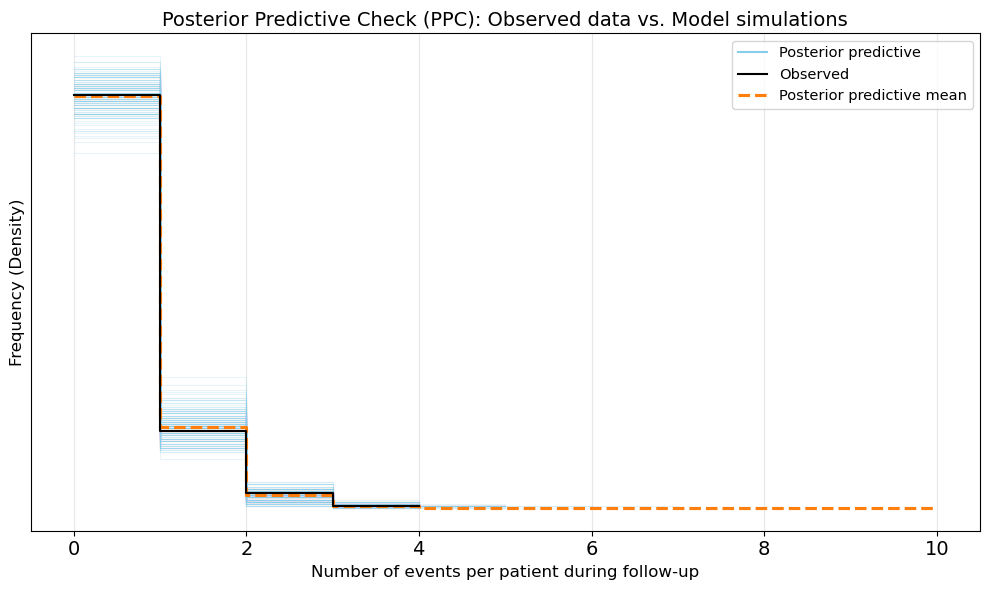

In [5]:
# Posterior Predictive Checks (PPC), goodness of fit
print("\nGenerating simulations for the Posterior Predictive Check...")

# Sample predictive data from the trained model
with modelo_bglm:
    pm.sample_posterior_predictive(trace, extend_inferencedata=True, random_seed=42)

# Generate the PPC plot with ArviZ
fig, ax = plt.subplots(figsize=(10, 6))

az.plot_ppc(
    trace, 
    num_pp_samples=150, # Nº of simulations drawn (blue lines)
    color="skyblue", 
    ax=ax
)

# Graph format
ax.set_title('Posterior Predictive Check (PPC): Observed data vs. Model simulations', fontsize=14)
ax.set_xlabel('Number of events per patient during follow-up', fontsize=12)
ax.set_ylabel('Frequency (Density)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

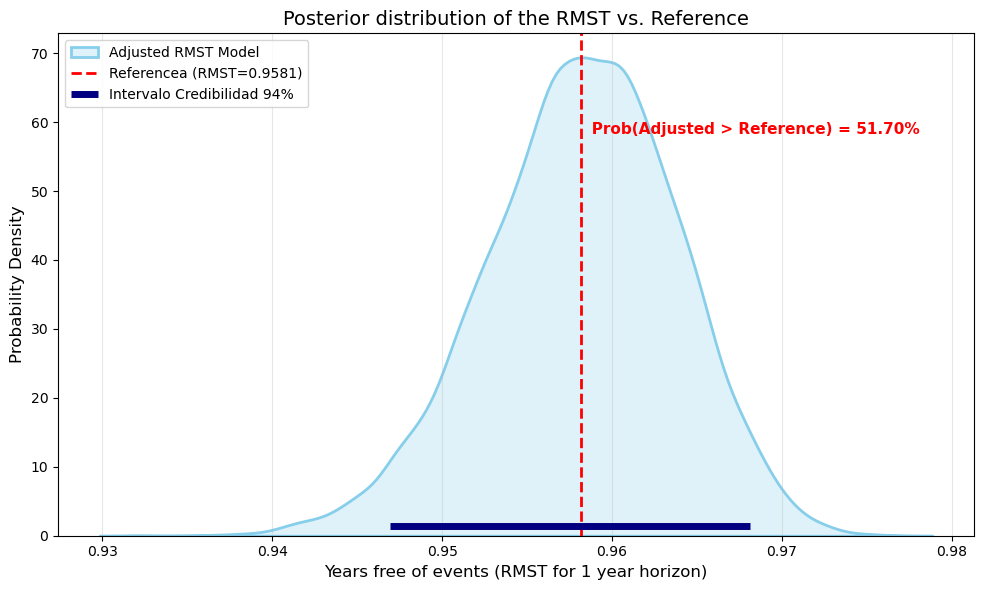

In [6]:
# Plot the results obtained from 'avg_rmst'
def comparative_rmst_graph(rmst_samples, rmst_ref):
    plt.figure(figsize=(10, 6))
    
    # Plot the distribution of the RMST samples
    sns.kdeplot(rmst_samples, fill=True, color="skyblue", label="Adjusted RMST Model", lw=2)
    
    # Plot the reference line
    plt.axvline(rmst_ref, color="red", linestyle="--", lw=2, label=f"Referencea (RMST={rmst_ref:.4f})")
    
    # Calculate the Credibility interval (HDI = 94%) to be plotterd as a shadow
    hdi_lower = np.percentile(rmst_samples, 3)
    hdi_upper = np.percentile(rmst_samples, 97)
    y_hdi = plt.gca().get_ylim()[1] * 0.02
    plt.hlines(y=y_hdi, xmin=hdi_lower, xmax=hdi_upper, color='navy', lw=5, label='Intervalo Credibilidad 94%')

    # Graph format
    plt.title("Posterior distribution of the RMST vs. Reference", fontsize=14)
    plt.xlabel("Years free of events (RMST for 1 year horizon)", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    prob_mayor = (rmst_samples > rmst_ref).mean()
    plt.text(rmst_ref, plt.gca().get_ylim()[1] * 0.8, f'  Prob(Adjusted > Reference) = {prob_mayor:.2%}', 
             color='red', fontweight='bold', fontsize=11)

    plt.legend(loc='upper left')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('RMST.png', dpi=300, bbox_inches='tight')
    plt.show()

# Call the function
comparative_rmst_graph(sample_rmst, avg_rmst)

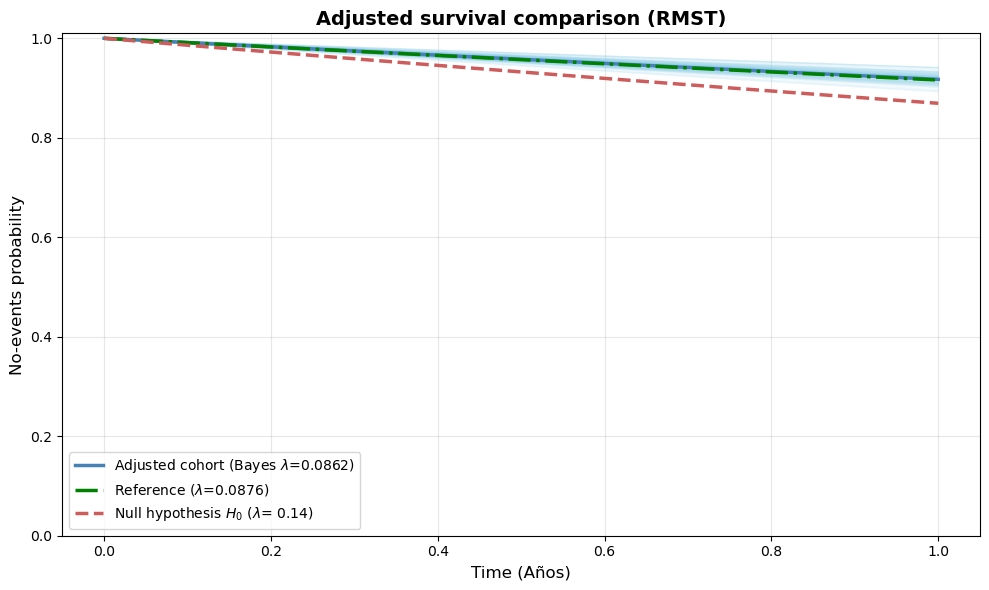

In [7]:
# Graph the RMST both the model and the H0 rate
def graph_bayesian_vs_ref_RMST(results, time_fu, ref_rate=0.0876, t_max_years=5.0):
    # Data preprocessing
    posterior = results.posterior
    time_array = np.asarray(time_fu)
    n_obs = len(time_array)
        
    # Prediction extracion
    if "lambda" in posterior:
        lambda_matrix = posterior["lambda"].values.reshape(-1, n_obs)
        lambda_individual_samples = lambda_matrix
    else:
        mu_matrix = posterior["mu"].values.reshape(-1, n_obs)
        lambda_individual_samples = mu_matrix / time_array
    
    # La tasa de la cohorte es la media de los pacientes en cada simulación MCMC
    lambda_samples = lambda_individual_samples.mean(axis=1)
    lambda_avg_obs = lambda_samples.mean()
    
    # Time axis
    t_axis = np.linspace(0, t_max_years, 100)
    
    # Survival curves
    s_ref = np.exp(-ref_rate * t_axis)
    s_adj = np.exp(-lambda_avg_obs * t_axis)
    
    # Graph plot
    plt.figure(figsize=(10, 6))
    
    # H0 survival curve plot
    s_h0 = np.exp(-0.14 * t_axis)
    
    # Credivility interval: 100 random rate samples
    sample_index = np.random.choice(len(lambda_samples), size=100, replace=False)
    for idx in sample_index:
        lmb = lambda_samples[idx]
        plt.plot(t_axis, np.exp(-lmb * t_axis), color='skyblue', alpha=0.1, lw=1)

    # Main distributions
    plt.plot(t_axis, s_adj, color='steelblue', lw=2.5, 
             label=f'Adjusted cohort (Bayes $\lambda$={lambda_avg_obs:.4f})')
    
    plt.plot(t_axis, s_ref, color='green', linestyle='-.', lw=2.5, 
             label=f'Reference ($\lambda$={ref_rate:.4f})')
    
    plt.plot(t_axis, s_h0, color='indianred', linestyle='--', lw=2.5, 
             label=r'Null hypothesis $H_0$ ($\lambda$= 0.14)')
             
    # Graph format
    plt.title("Adjusted survival comparison (RMST)", fontsize=14, fontweight='bold')
    plt.xlabel("Time (Años)", fontsize=12)
    plt.ylabel("No-events probability", fontsize=12)
    plt.ylim(0, 1.01)
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    
    # Shadowing of the distribution differences
    plt.fill_between(t_axis, s_adj, s_ref, color='gray', alpha=0.2, label='RMST difference')
    
    plt.tight_layout()
    plt.savefig('graph_RMST_Supervivencia.png', dpi=300, bbox_inches='tight')
    plt.show()
    
# Call the function
graph_bayesian_vs_ref_RMST(trace, df_sim['times'], ref_rate=0.0876, t_max_years=1.0)

In [8]:
# Prediction comparison with the real number of events
def compare_predict(results, obs_events, ppc_var_name='n.events'):
    # Extract the predictive simulations from the ppc analysis stored in 'results'
    predict = results.posterior_predictive[ppc_var_name]
    
    # Dynamic search of the observation's dimension
    dim_obs = [d for d in predict.dims if d not in ['chain', 'draw']][0]
    
    # Addition of the events predicted for each simulation
    tot_events_sim = predict.sum(dim=dim_obs).values.flatten()
    
    # Calculate the predicted average and the HDI = 94%
    avg_pred = tot_events_sim.mean()
    hdi_3 = np.percentile(tot_events_sim, 3)
    hdi_97 = np.percentile(tot_events_sim, 97)
    
    # Real Nº of events
    real_events = np.asarray(obs_events).sum()
    
    # Graph the results
    print("--- GOODNESS OF FIT: OBSERVED vs EXPECTED ---")
    print(f"Nº of REAL events:     {real_events}")
    print(f"Nº of PREDICTED events by the model: {avg_pred:.1f} (HDI 94%: {hdi_3:.1f} a {hdi_97:.1f})")
    print("-" * 50)
    
    if hdi_3 <= real_events <= hdi_97:
        print("✅ SUCCESS: The number of real events is in the prediction interval of the model.")
    else:
        print("⚠️ WARNING: The model overestimates or understimates the number of events.")
        
# Call the function        
compare_predict(trace, events, 'obs_rate')

--- GOODNESS OF FIT: OBSERVED vs EXPECTED ---
Nº of REAL events:     53
Nº of PREDICTED events by the model: 52.9 (HDI 94%: 35.0 a 73.0)
--------------------------------------------------
✅ SUCCESS: The number of real events is in the prediction interval of the model.


In [9]:
# Compute the Corcondance Index (C-Statistic) based on the event rate 
def c_statistic(results, obs_events, time_fu, ppc_var_name='obs_events'):
    # Extract the expected event parameter
    predict = results.posterior_predictive[ppc_var_name]
    dim_obs = [d for d in predict.dims if d not in ['chain', 'draw']][0]
    exp_events = predict.mean(dim=["chain", "draw"]).values
    
    r_time = np.asarray(time_fu)
    r_events = np.asarray(obs_events)
    
    # Calculate the risk rate (Lambda = Events / Time)
    risk_rate = exp_events / r_time
    
    # Calculate C-Index
    c_index = concordance_index(r_time, -risk_rate, r_events)
    
    # Print the results
    print("--- DISCRIMINATION CAPACITY (C-STATISTIC) ---")
    print(f"C-Index: {c_index:.4f}")
    print("-" * 50)
    
    if c_index >= 0.8:
        print("Interpretation: EXCELENT. The model distinguishes almost perfectly the risk.")
    elif c_index >= 0.7:
        print("Interpretation: GOOD. Clinical standard.")
    elif c_index >= 0.6:
        print("Interpretation: ACCECPTABLE. There's a slight discrimination capacity, with an improvement margin.")
    else:
        print("Interpretation: POOR. Insuficient predictive capacity.")
        
    return c_index

# Call the function
c_index = c_statistic(trace, events, time, 'obs_rate')

--- DISCRIMINATION CAPACITY (C-STATISTIC) ---
C-Index: 0.6409
--------------------------------------------------
Interpretation: ACCECPTABLE. There's a slight discrimination capacity, with an improvement margin.


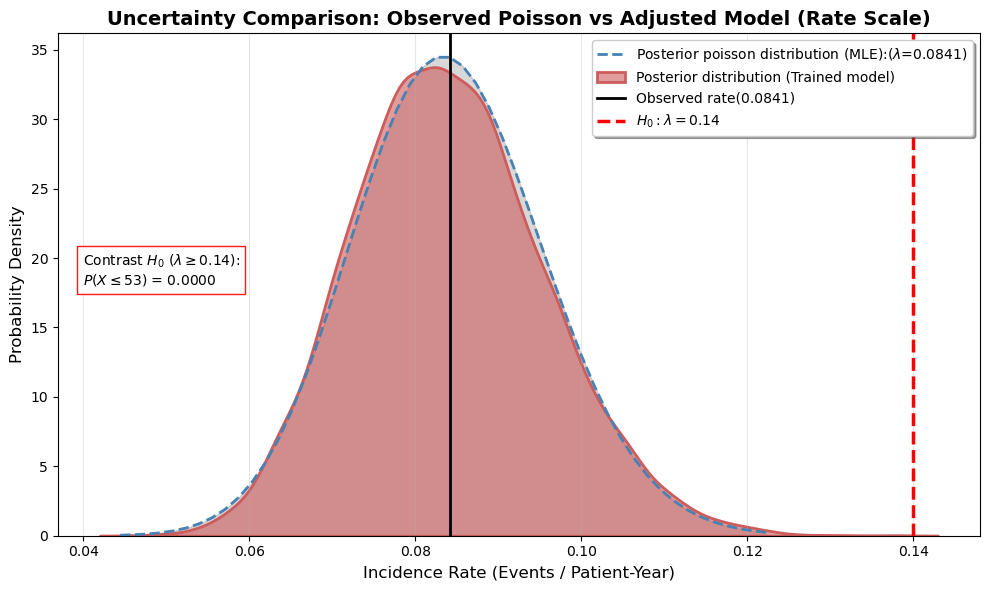

In [10]:
def graficar_poisson_vs_modelo_tasa(results, obs_events, time_fu, ppc_var_name='n.events'):
    plt.figure(figsize=(10, 6))
    
    # --- 1. DATOS EMPÍRICOS Y TIEMPO ---
    # Convertimos a arrays de NumPy para independizarnos del DataFrame
    time_array = np.asarray(time_fu)
        
    time_tot = time_array.sum()
    
    r_events = int(np.asarray(obs_events).sum())
    r_rate = r_events / time_tot
    
    # Poisson distribution
    # X axis (Events and rate)
    x_events = np.arange(max(0, r_events - 25), r_events + 25)
    x_rate = x_events / time_tot
    
    # Calculate the Probability Mass Function (PMF) and convert it into density distribution
    y_pmf = poisson.pmf(x_events, mu=r_events)
    y_density_poisson = y_pmf * time_tot 
    
    # CDF, Probability to observe #events or less if the rate were 0.14?
    exp_events_h0 = 0.14 * time_tot
    p_valor_poisson = poisson.cdf(r_events, mu=exp_events_h0)
    
    # Model distribution (Bayesian posterior)
    n_obs = len(time_array)
    posterior = results.posterior
    
    # Dynamic search of the rate's prediction
    if "mu" in posterior:
        mu_matrix = posterior["mu"].values.reshape(-1, n_obs)
        tot_sim_events = mu_matrix.sum(axis=1)
    elif "lambda" in posterior:
        lambda_matrix = posterior["lambda"].values.reshape(-1, n_obs)
        mu_matrix = lambda_matrix * time_array
        tot_sim_events = mu_matrix.sum(axis=1)
    else:
        # Fallback to the posterior prediction if no parameters were stored
        predict = results.posterior_predictive[ppc_var_name]
        dim_obs = [d for d in predict.dims if d not in ['chain', 'draw']][0]
        tot_sim_events = predict.sum(dim=dim_obs).values.flatten()

    sim_rate = tot_sim_events / time_tot

    # Graphs
    # Posterior distribution of the original empirical Poisson
    plt.plot(x_rate, y_density_poisson, color='steelblue', lw=2, linestyle='--', 
             label=f'Posterior poisson distribution (MLE):($\lambda$={r_rate:.4f})')
    plt.fill_between(x_rate, y_density_poisson, color='gray', alpha=0.3)

    # Posterior distribution of the trained model
    sns.kdeplot(sim_rate, fill=True, color="indianred", alpha=0.6, 
                label="Posterior distribution (Trained model)", lw=2)
    
    # Observed rate of the model 
    plt.axvline(r_rate, color="black", linestyle="-", lw=2, 
                label=f"Observed rate({r_rate:.4f})")
    
    # Null Hypothesis Line
    plt.axvline(0.14, color='red', linestyle='--', linewidth=2.5, 
                label=r'$H_0: \lambda = 0.14$')

    # Graph format
    plt.title("Uncertainty Comparison: Observed Poisson vs Adjusted Model (Rate Scale)", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Incidence Rate (Events / Patient-Year)", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    
    # Print the p-value of the null hypothesis in the figure 
    plt.text(plt.gca().get_xlim()[0] + (plt.gca().get_xlim()[1]*0.02), plt.gca().get_ylim()[1] * 0.5, 
             f'Contrast $H_0$ ($\lambda \geq 0.14$):\n$P(X \leq {r_events})$ = {p_valor_poisson:.4f}', 
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='red'))

    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('Distribucion_Poisson_Tasa.png', dpi=300, bbox_inches='tight')
    plt.show()

graficar_poisson_vs_modelo_tasa(trace, events, time, 'obs_rate')